<a href="https://colab.research.google.com/github/chinmay227/indian-market-internals/blob/main/03_expand_universe_and_breadth.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Market Breadth Analysis

This notebook studies whether Nifty moves are supported by broad participation across stocks.

The goal is to calculate breadth indicators such as:

- Percentage of stocks beating Nifty
- Percentage of stocks above their 50-day moving average
- Percentage of stocks above their 200-day moving average
- Median stock return versus Nifty return

These indicators will later be used to test whether momentum works better in broad markets and mean reversion works better in weak or narrow markets.

In [ ]:
!pip -q install yfinance pandas numpy matplotlib

In [ ]:
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
from pathlib import Path

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 120)

In [ ]:
START_DATE = "2018-01-01"

INDEX_TICKER = "^NSEI"

STOCK_TICKERS = [
    "RELIANCE.NS",
    "TCS.NS",
    "HDFCBANK.NS",
    "ICICIBANK.NS",
    "INFY.NS",
    "HINDUNILVR.NS",
    "ITC.NS",
    "LT.NS",
    "SBIN.NS",
    "BHARTIARTL.NS",
    "AXISBANK.NS",
    "KOTAKBANK.NS",
    "BAJFINANCE.NS",
    "ASIANPAINT.NS",
    "MARUTI.NS",
    "HCLTECH.NS",
    "SUNPHARMA.NS",
    "TMCV.NS",
    "TITAN.NS",
    "ULTRACEMCO.NS",
    "NESTLEIND.NS",
    "POWERGRID.NS",
    "NTPC.NS",
    "ONGC.NS",
    "COALINDIA.NS",
]

TICKERS = [INDEX_TICKER] + STOCK_TICKERS

print("Total tickers:", len(TICKERS))

Total tickers: 26


In [ ]:
raw = yf.download(
    tickers=TICKERS,
    start=START_DATE,
    auto_adjust=True,
    group_by="ticker",
    multi_level_index=True,
    progress=False,
    threads=True
)

raw.head()

Ticker         INFY.NS                                               KOTAKBANK.NS                                      \
Price             Open        High         Low       Close    Volume         Open        High         Low       Close   
Date                                                                                                                    
2018-01-01  408.080884  410.755039  405.052838  406.448914   5431340   200.969738  201.039261  197.980571  198.606216   
2018-01-02  407.903910  409.771872  402.300024  404.934814   6112248   198.814797  199.807878  197.126562  199.251755   
2018-01-03  404.463034  405.682116  400.569798  401.631592   6846552   199.132557  199.986607  198.238775  198.636017   
2018-01-04  401.513591  401.513591  397.030471  399.311371   8947614   198.814798  199.192173  197.841583  198.695633   
2018-01-05  399.272042  403.637189  395.614773  397.974304  11025976   199.112715  199.946899  197.940887  199.221954   

Ticker                         ^NSEI                                                     SUNPHARMA.NS              \
Price           Volume          Open          High           Low         Close    Volume         Open        High   
Date                                                                                                                
2018-01-01   6587075.0           NaN           NaN           NaN           NaN       NaN   527.927814  540.768076   
2018-01-02   5361035.0  10477.549805  10495.200195  10404.650391  10442.200195  153400.0   533.008525  537.627317   
2018-01-03   4420105.0  10482.650391  10503.599609  10429.549805  10443.200195  167300.0   531.161170  534.810027   
2018-01-04   3919750.0  10469.400391  10513.000000  10441.450195  10504.799805  174900.0   528.389839  539.428763   
2018-01-05  10737010.0  10534.250000  10566.099609  10520.099609  10558.849609  180900.0   540.398673  542.569483   

Ticker                                            SBIN.NS                                                ...  \
Price              Low       Close     Volume        Open        High         Low       Close    Volume  ...   
Date                                                                                                     ...   
2018-01-01  527.696875  530.283386  5314142.0  281.521326  283.470035  277.623879  278.348999  12182400  ...   
2018-01-02  523.955706  528.528320  3839130.0  280.071115  280.071115  273.137321  274.859436  14797364  ...   
2018-01-03  523.771101  525.664795  2182632.0  276.717499  277.759857  273.862411  274.496887  13857373  ...   
2018-01-04  517.397090  536.888428  6246746.0  275.992404  281.158775  274.768787  279.617920  24517099  ...   
2018-01-05  531.438205  534.625183  4600683.0  282.246423  282.246423  276.989436  277.669220  14580575  ...   

Ticker            LT.NS                                                   HDFCBANK.NS                          \
Price              Open         High          Low        Close     Volume        Open        High         Low   
Date                                                                                                            
2018-01-01  1107.894355  1119.315947  1103.413599  1107.630737  2048058.0  429.826311  431.673976  424.730928   
2018-01-02  1113.165950  1115.713865  1091.948125  1098.010376  1512324.0  426.578581  430.354211  426.578581   
2018-01-03  1103.413700  1128.057918  1099.547909  1120.458252  2720736.0  430.354212  431.100160  424.891572   
2018-01-04  1128.936424  1159.730835  1124.675313  1155.952881  4546456.0  425.304719  428.173747  425.304719   
2018-01-05  1164.123799  1167.594163  1149.187871  1155.250122  2418902.0  427.599994  428.759092  425.890064   

Ticker                            BHARTIARTL.NS                                                ULTRACEMCO.NS  \
Price            Close     Volume          Open        High         Low       Close     Volume          Open   
Date                                                                

In [ ]:
downloaded_tickers = sorted(set(raw.columns.get_level_values(0)))
missing_tickers = [ticker for ticker in TICKERS if ticker not in downloaded_tickers]

print("Downloaded tickers:", len(downloaded_tickers))
print("Missing tickers:", missing_tickers)

Downloaded tickers: 26
Missing tickers: []


In [ ]:
close_prices = pd.DataFrame()

for ticker in TICKERS:
    if ticker in downloaded_tickers:
        close_prices[ticker] = raw[ticker]["Close"]

close_prices.index = pd.to_datetime(close_prices.index)
close_prices.index.name = "Date"

close_prices = close_prices.rename(columns={INDEX_TICKER: "NIFTY"})
close_prices = close_prices.dropna(how="all")

close_prices.tail()

,NIFTY,RELIANCE.NS,TCS.NS,HDFCBANK.NS,ICICIBANK.NS,INFY.NS,HINDUNILVR.NS,ITC.NS,LT.NS,SBIN.NS,BHARTIARTL.NS,AXISBANK.NS,KOTAKBANK.NS,BAJFINANCE.NS,ASIANPAINT.NS,MARUTI.NS,HCLTECH.NS,SUNPHARMA.NS,TMCV.NS,TITAN.NS,ULTRACEMCO.NS,NESTLEIND.NS,POWERGRID.NS,NTPC.NS,ONGC.NS,COALINDIA.NS
Date,,,,,,,,,,,,,,,,,,,,,,,,,,
2026-08-10,24583.800781,1327.300049,2425.699951,731.0,1431.800049,1183.000000,2087.199951,282.649994,4080.000000,1071.000000,1943.000000,1247.300049,393.500000,1102.199951,2750.000000,14097.0,1357.199951,1944.400024,450.200012,5090.000000,12038.0,1528.599976,270.100006,340.450012,239.839996,411.000000
2026-08-11,24471.699219,1323.900024,2445.699951,729.0,1429.599976,1190.699951,2064.899902,279.000000,4037.399902,1066.000000,1915.199951,1229.800049,392.899994,1093.300049,2735.500000,13990.0,1365.400024,1942.000000,450.049988,5128.000000,11780.0,1493.199951,267.950012,338.450012,239.449997,412.600006
2026-08-12,24435.949219,1329.000000,2349.699951,729.0,1431.699951,1176.099976,2063.000000,276.149994,4020.000000,1082.000000,1945.000000,1230.000000,390.500000,1094.199951,2740.000000,13875.0,1365.400024,1944.000000,457.049988,5099.000000,11891.0,1507.000000,269.450012,339.450012,239.050003,409.299988
2026-08-13,24395.849609,1317.000000,2375.000000,725.0,1406.800049,1175.000000,2092.000000,278.500000,4070.699951,1083.000000,1939.099976,1221.800049,392.399994,1090.800049,2755.500000,13905.0,1370.000000,1932.000000,474.799988,5063.700195,11706.0,1506.900024,266.600006,344.250000,239.899994,410.500000
2026-08-14,24366.000000,1310.000000,2361.000000,727.0,1417.000000,1169.199951,2077.000000,278.200012,4057.000000,1067.699951,1992.099976,1217.400024,391.149994,1087.000000,2696.300049,13834.0,1360.000000,1930.000000,474.299988,5056.200195,11619.0,1499.099976,266.049988,340.000000,236.399994,407.100006


In [ ]:
stock_cols = [col for col in close_prices.columns if col != "NIFTY"]

ma_50 = close_prices[stock_cols].rolling(50).mean()
ma_200 = close_prices[stock_cols].rolling(200).mean()

above_50dma = (close_prices[stock_cols] > ma_50).where(ma_50.notna())
above_200dma = (close_prices[stock_cols] > ma_200).where(ma_200.notna())

breadth_daily = pd.DataFrame(index=close_prices.index)

breadth_daily["pct_above_50dma"] = above_50dma.mean(axis=1)
breadth_daily["pct_above_200dma"] = above_200dma.mean(axis=1)

breadth_daily.tail()

,pct_above_50dma,pct_above_200dma
Date,,
2026-08-10,0.727273,0.454545
2026-08-11,0.727273,0.454545
2026-08-12,0.727273,0.454545
2026-08-13,0.727273,0.454545
2026-08-14,0.636364,0.454545


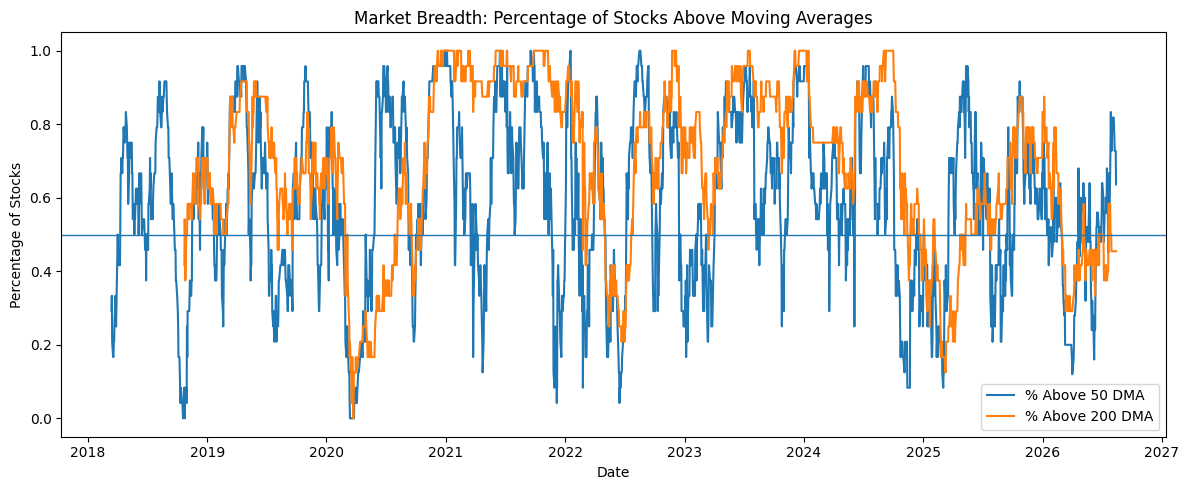

In [ ]:
plt.figure(figsize=(12, 5))
plt.plot(breadth_daily.index, breadth_daily["pct_above_50dma"], label="% Above 50 DMA")
plt.plot(breadth_daily.index, breadth_daily["pct_above_200dma"], label="% Above 200 DMA")
plt.axhline(0.5, linewidth=1)
plt.title("Market Breadth: Percentage of Stocks Above Moving Averages")
plt.ylabel("Percentage of Stocks")
plt.xlabel("Date")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
monthly_prices = close_prices.resample("M").last()

return_windows = {
    "1M": 1,
    "3M": 3,
    "6M": 6,
    "12M": 12,
}

breadth_monthly = pd.DataFrame(index=monthly_prices.index)

for label, months in return_windows.items():
    stock_returns = monthly_prices[stock_cols].pct_change(months)
    nifty_returns = monthly_prices["NIFTY"].pct_change(months)

    relative_returns = stock_returns.sub(nifty_returns, axis=0)

    beating_nifty = (relative_returns > 0).where(relative_returns.notna())

    breadth_monthly[f"pct_stocks_beating_nifty_{label}"] = beating_nifty.mean(axis=1)
    breadth_monthly[f"median_relative_return_{label}"] = relative_returns.median(axis=1)

breadth_monthly.tail()

/tmp/ipykernel_1242/3461450858.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_prices = close_prices.resample("M").last()


,pct_stocks_beating_nifty_1M,median_relative_return_1M,pct_stocks_beating_nifty_3M,median_relative_return_3M,pct_stocks_beating_nifty_6M,median_relative_return_6M,pct_stocks_beating_nifty_12M,median_relative_return_12M
Date,,,,,,,,
2026-04-30,0.56,0.002282,0.6,0.044177,0.583333,0.033234,0.666667,0.035260
2026-05-31,0.4,-0.011939,0.48,-0.005535,0.6,0.030778,0.625,0.081748
2026-06-30,0.44,-0.013330,0.44,-0.008783,0.64,0.086837,0.666667,0.064609
2026-07-31,0.52,0.013568,0.48,-0.022443,0.56,0.004421,0.666667,0.070178
2026-08-31,0.32,-0.011850,0.44,-0.005805,0.32,-0.024022,0.583333,0.046334


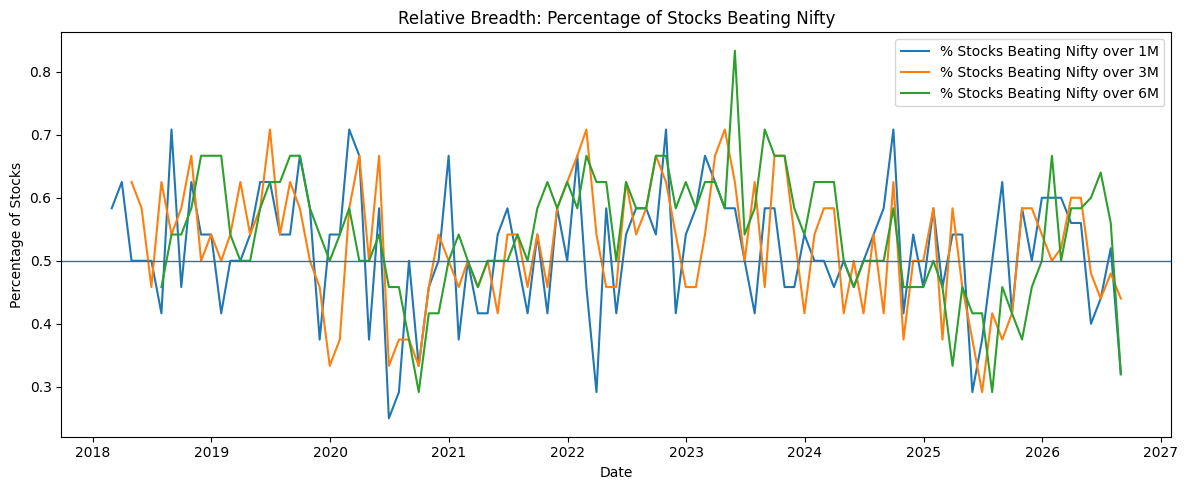

In [ ]:
plt.figure(figsize=(12, 5))
plt.plot(
    breadth_monthly.index,
    breadth_monthly["pct_stocks_beating_nifty_1M"],
    label="% Stocks Beating Nifty over 1M"
)
plt.plot(
    breadth_monthly.index,
    breadth_monthly["pct_stocks_beating_nifty_3M"],
    label="% Stocks Beating Nifty over 3M"
)
plt.plot(
    breadth_monthly.index,
    breadth_monthly["pct_stocks_beating_nifty_6M"],
    label="% Stocks Beating Nifty over 6M"
)
plt.axhline(0.5, linewidth=1)
plt.title("Relative Breadth: Percentage of Stocks Beating Nifty")
plt.ylabel("Percentage of Stocks")
plt.xlabel("Date")
plt.legend()
plt.tight_layout()
plt.show()

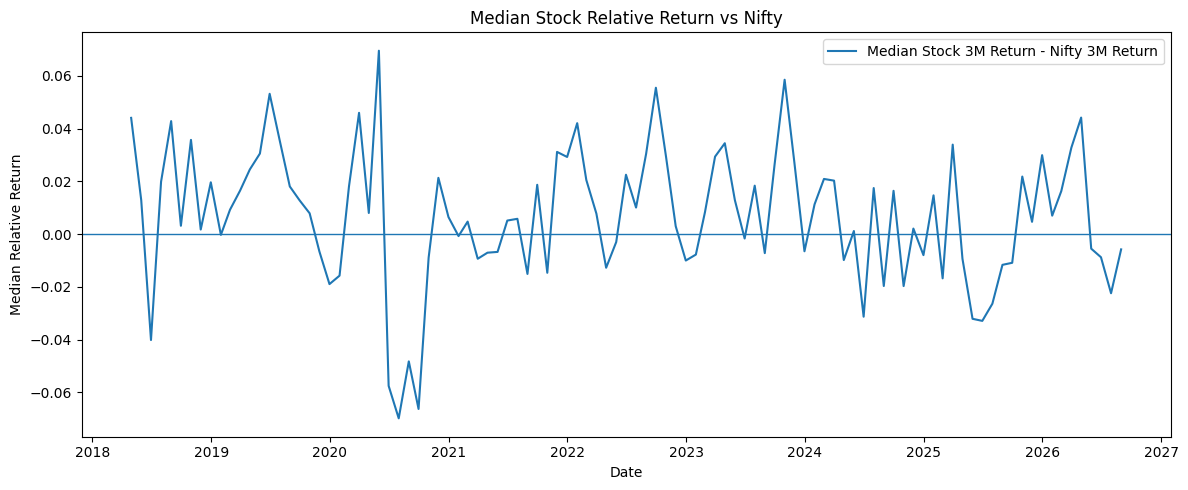

In [ ]:
plt.figure(figsize=(12, 5))
plt.plot(
    breadth_monthly.index,
    breadth_monthly["median_relative_return_3M"],
    label="Median Stock 3M Return - Nifty 3M Return"
)
plt.axhline(0, linewidth=1)
plt.title("Median Stock Relative Return vs Nifty")
plt.ylabel("Median Relative Return")
plt.xlabel("Date")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
breadth_monthly["breadth_regime_3M"] = np.where(
    breadth_monthly["pct_stocks_beating_nifty_3M"] >= 0.60,
    "Broad Strength",
    np.where(
        breadth_monthly["pct_stocks_beating_nifty_3M"] <= 0.40,
        "Narrow/Weak Breadth",
        "Neutral Breadth"
    )
)

breadth_monthly.loc[
    breadth_monthly["pct_stocks_beating_nifty_3M"].isna(),
    "breadth_regime_3M"
] = np.nan

breadth_monthly[
    [
        "pct_stocks_beating_nifty_3M",
        "median_relative_return_3M",
        "breadth_regime_3M"
    ]
].tail(20)

,pct_stocks_beating_nifty_3M,median_relative_return_3M,breadth_regime_3M
Date,,,
2025-01-31,0.583333,0.014676,Neutral Breadth
2025-02-28,0.375,-0.016793,Narrow/Weak Breadth
2025-03-31,0.583333,0.033913,Neutral Breadth
2025-04-30,0.458333,-0.009365,Neutral Breadth
2025-05-31,0.375,-0.032132,Narrow/Weak Breadth
2025-06-30,0.291667,-0.032921,Narrow/Weak Breadth
2025-07-31,0.416667,-0.026411,Neutral Breadth
2025-08-31,0.375,-0.011669,Narrow/Weak Breadth
2025-09-30,0.416667,-0.010893,Neutral Breadth


In [ ]:
breadth_monthly["breadth_regime_3M"].value_counts(dropna=False)

,count
breadth_regime_3M,
Neutral Breadth,67
Broad Strength,23
Narrow/Weak Breadth,11
NaN,3


In [ ]:
output_dir = Path("/content/indian-market-internals-output")
output_dir.mkdir(parents=True, exist_ok=True)

breadth_daily.to_csv(output_dir / "daily_moving_average_breadth.csv")
breadth_monthly.to_csv(output_dir / "monthly_relative_breadth.csv")

print("Saved files:")
for file in output_dir.iterdir():
    print(file)

Saved files:
/content/indian-market-internals-output/monthly_relative_breadth.csv
/content/indian-market-internals-output/daily_moving_average_breadth.csv


## Initial Breadth Analysis

This notebook creates the first set of market breadth indicators.

The key idea is that index-level performance can hide what is happening underneath. Nifty may rise even when only a small number of stocks are leading, or it may understate broad strength when many stocks are outperforming beneath the surface.

The first version measures:

- Percentage of stocks above their 50-day moving average
- Percentage of stocks above their 200-day moving average
- Percentage of stocks beating Nifty over 1M, 3M, 6M, and 12M periods
- Median stock relative return versus Nifty
- Simple breadth regime labels

The next step is to connect these breadth regimes to the momentum and mean-reversion tests.